<a href="https://colab.research.google.com/github/thanusree02/Natural-Language-Processing/blob/main/NLP_LAB_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

Load and Preprocess Data

In [12]:
# Load dataset
data = pd.read_csv("/content/movie_reviews.csv")

# Display first few rows
print(data.head())

                                           review sentiment
0  Wonderful direction and brilliant performances  positive
1                     Absolutely loved this movie  positive
2               One of the best films I have seen  positive
3     The film was inspiring and beautifully made  positive
4       Outstanding performance by the lead actor  positive


Text Cleaning

In [13]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data['clean_review'] = data['review'].apply(clean_text)

print(data[['review','clean_review']].head())

                                           review  \
0  Wonderful direction and brilliant performances   
1                     Absolutely loved this movie   
2               One of the best films I have seen   
3     The film was inspiring and beautifully made   
4       Outstanding performance by the lead actor   

                                 clean_review  
0  wonderful direction brilliant performances  
1                      absolutely loved movie  
2                         one best films seen  
3             film inspiring beautifully made  
4          outstanding performance lead actor  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(TF-IDF)

In [14]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(data['clean_review'])

y = data['sentiment']
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 57


Train Logistic Regression Model (Split Dataset)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model




In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Model Evaluation (Predictions)

In [17]:
y_pred = model.predict(X_test)

Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Precision, Recall, F1

In [19]:
precision = precision_score(y_test, y_pred, pos_label='positive')
recall = recall_score(y_test, y_pred, pos_label='positive')
f1 = f1_score(y_test, y_pred, pos_label='positive')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Confusion Matrix

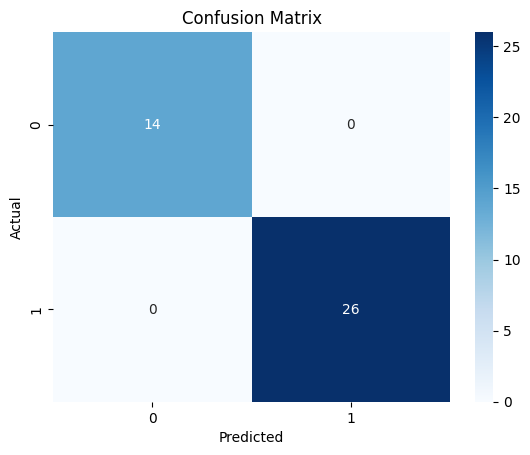

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()